# <font color="#4DAAFC"><strong>Gradient Descent: From Intuition to Implementation</strong></font>

**CH3RRY PI3 Data Science Learning Labs**

Gradient descent is the optimisation engine behind a large part of modern machine learning. This Learning Lab develops it without treating it as a black box: we will examine a slope, perform an update by hand, implement the pieces as focused Python functions and finally fit a straight line to data.

**Intended audience:** readers comfortable with introductory Python and basic algebra  
**Prerequisites:** functions, squares, sums and the idea that a derivative measures slope  
**Estimated study time:** 60–90 minutes  
**Last reviewed:** 13 August 2026


## <font color="#4DAAFC"><strong>Learning objectives</strong></font>

By the end of this Learning Lab, you should be able to:

1. explain gradient descent as an iterative optimisation method;
2. interpret a gradient as a direction and rate of change;
3. perform one gradient-descent update by hand;
4. implement batch gradient descent for simple linear regression; and
5. diagnose the effects of a learning rate that is too small or too large.


## <font color="#4DAAFC"><strong>Contents</strong></font>

1. [Imports and reproducibility](#imports)
2. [The optimisation problem](#optimisation-problem)
3. [Start with one parameter](#one-parameter)
   - [The gradient](#one-parameter-gradient)
   - [One hand-worked update](#worked-update)
   - [Implement one update](#implement-update)
4. [The learning rate](#learning-rate)
5. [Move from one parameter to a fitted line](#linear-regression)
   - [Model and loss](#model-loss)
   - [Gradients](#linear-gradients)
   - [One vectorised gradient calculation](#gradient-function)
6. [Assemble batch gradient descent](#fit-runner)
7. [Fit and inspect the model](#fit-model)
8. [Compare learning rates](#compare-rates)
9. [Sanity checks and limitations](#checks)
10. [Summary and next steps](#summary)


<a id="imports"></a>
## <font color="#4DAAFC"><strong>1. Imports and reproducibility</strong></font>

NumPy supplies vector operations and a reproducible random-number generator. Matplotlib displays the objective function, fitted line and optimisation history. The fixed seed ensures that the synthetic demonstration data remain the same when the notebook is rerun.


In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

SEED = 5901
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#4DAAFC"
RED = "#E53935"
GREEN = "#18A957"


<a id="optimisation-problem"></a>
## <font color="#4DAAFC"><strong>2. The optimisation problem</strong></font>

An optimisation problem asks us to choose values that make an objective as small or as large as possible. In supervised machine learning, the objective is often a **loss function** that measures disagreement between predictions and observed outcomes.

Let $\boldsymbol{\theta}\in\mathbb{R}^{d}$ be a vector containing the model's $d$ adjustable parameters. Let $J(\boldsymbol{\theta})$ be the loss produced by those parameters. Training seeks

$$
\boldsymbol{\theta}^{*}
=\underset{\boldsymbol{\theta}}{\operatorname{arg\,min}}\;
J(\boldsymbol{\theta}), \tag{2.1}
$$

where $\boldsymbol{\theta}^{*}$ denotes a parameter vector that minimises the loss.

Equation (2.1) can be read as: among all possible parameter values, find the choice that produces the smallest loss. Gradient descent approaches this minimum through a sequence of controlled updates rather than attempting to jump there in one step.


<a id="one-parameter"></a>
## <font color="#4DAAFC"><strong>3. Start with one parameter</strong></font>

Before fitting a model with several parameters, consider the one-parameter objective

$$
J(\theta)=(\theta-3)^2, \tag{3.1}
$$

where $\theta\in\mathbb{R}$ is the adjustable parameter. The square makes the loss non-negative, and the loss reaches zero when $\theta=3$.

This example gives us a known destination. It allows us to inspect how gradient descent moves without the additional machinery of a full model.


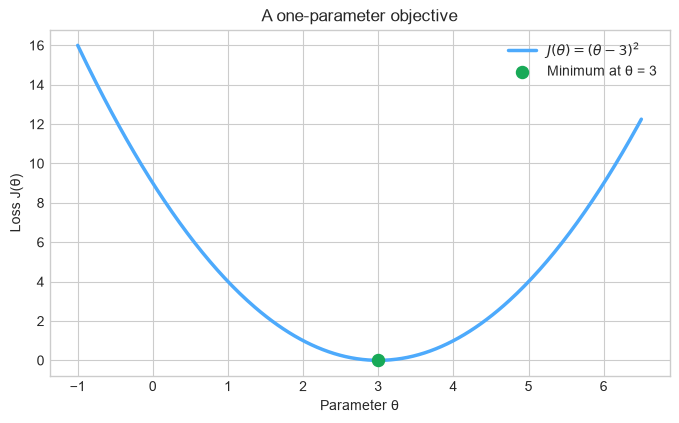

In [2]:
theta_grid = np.linspace(-1.0, 6.5, 300)
objective_grid = (theta_grid - 3.0) ** 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, objective_grid, color=BLUE, linewidth=2.5, label=r"$J(\theta)=(\theta-3)^2$")
ax.scatter([3.0], [0.0], color=GREEN, s=75, zorder=3, label="Minimum at θ = 3")
ax.set(title="A one-parameter objective", xlabel="Parameter θ", ylabel="Loss J(θ)")
ax.legend()
plt.show()


The curve is bowl-shaped. Values far from 3 produce a large squared loss, while moving towards 3 reduces it. The labelled point identifies the known minimum; colour is not required to distinguish it because the legend also names it.


<a id="one-parameter-gradient"></a>
### <font color="#4DAAFC"><strong>3.1 The gradient gives a direction</strong></font>

For a function with one parameter, the gradient is simply its derivative. Differentiating equation (3.1) gives

$$
\frac{\mathrm{d}J}{\mathrm{d}\theta}=2(\theta-3). \tag{3.2}
$$

The sign supplies a direction:

| Current position | Gradient sign | Direction that reduces the loss |
|---|---:|---|
| $\theta<3$ | Negative | Increase $\theta$ |
| $\theta=3$ | Zero | No update is needed |
| $\theta>3$ | Positive | Decrease $\theta$ |

Gradient descent uses the update

$$
\theta^{(t+1)}
=\theta^{(t)}-\alpha
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=\theta^{(t)}}, \tag{3.3}
$$

where $t$ is the current iteration and $\alpha>0$ is the **learning rate**. The learning rate controls the size of the step.

Equation (3.3) says: evaluate the slope at the current parameter, scale it by the learning rate and move in the opposite direction. Subtracting a positive gradient moves left; subtracting a negative gradient moves right.


<a id="worked-update"></a>
### <font color="#4DAAFC"><strong>3.2 One hand-worked update</strong></font>

Suppose the initial parameter is $\theta^{(0)}=0$ and the learning rate is $\alpha=0.1$.

First calculate the gradient:

$$
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=0}
=2(0-3)=-6.
$$

Now substitute it into equation (3.3):

$$
\theta^{(1)}=0-(0.1)(-6)=0.6.
$$

The parameter moves from 0 to 0.6—towards the minimum at 3. The loss falls from

$$J(0)=9$$

to

$$J(0.6)=(0.6-3)^2=5.76.$$

This single update does not solve the problem, but it has moved in a useful direction and reduced the objective.


<a id="implement-update"></a>
### <font color="#4DAAFC"><strong>3.3 Implement one update</strong></font>

The following functions separate the objective, gradient and update. That separation makes the mathematical correspondence visible and allows each part to be tested independently.


In [3]:
def quadratic_objective(theta: float) -> float:
    """Evaluate the demonstration objective ``(theta - 3)^2``.

    Parameters
    ----------
    theta
        Current scalar parameter value.

    Returns
    -------
    float
        Non-negative objective value.
    """
    return float((theta - 3.0) ** 2)


def quadratic_gradient(theta: float) -> float:
    """Evaluate the derivative of the demonstration objective.

    Parameters
    ----------
    theta
        Current scalar parameter value.

    Returns
    -------
    float
        Gradient ``2 * (theta - 3)`` at the supplied point.
    """
    return float(2.0 * (theta - 3.0))


def gradient_step(theta: float, gradient: float, learning_rate: float) -> float:
    """Apply one scalar gradient-descent update.

    Parameters
    ----------
    theta
        Parameter value before the update.
    gradient
        Objective gradient evaluated at ``theta``.
    learning_rate
        Positive step-size multiplier.

    Returns
    -------
    float
        Updated parameter value.

    Raises
    ------
    ValueError
        If the learning rate is not positive and finite.
    """
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("learning_rate must be positive and finite")
    return float(theta - learning_rate * gradient)


In [4]:
theta_0 = 0.0
gradient_0 = quadratic_gradient(theta_0)
theta_1 = gradient_step(theta_0, gradient_0, learning_rate=0.1)

print(f"Initial theta: {theta_0:.1f}")
print(f"Initial gradient: {gradient_0:.1f}")
print(f"Updated theta: {theta_1:.1f}")
print(f"Loss before update: {quadratic_objective(theta_0):.2f}")
print(f"Loss after update: {quadratic_objective(theta_1):.2f}")


Initial theta: 0.0
Initial gradient: -6.0
Updated theta: 0.6
Loss before update: 9.00
Loss after update: 5.76


The output reproduces the hand calculation: the negative gradient moves the parameter from 0.0 to 0.6, and the loss falls from 9.00 to 5.76. Matching the manual and coded results is our first sanity check.


<a id="learning-rate"></a>
## <font color="#4DAAFC"><strong>4. The learning rate controls the journey</strong></font>

The learning rate $\alpha$ is not the direction of travel; the gradient already supplies that. It controls how far the parameter travels during each update.

- A very small learning rate can make progress unnecessarily slow.
- A suitable learning rate can approach the minimum smoothly.
- A learning rate that is too large can overshoot, oscillate or diverge.

The next function records a complete path so that we can inspect these behaviours rather than relying on the final value alone.


In [5]:
def trace_quadratic_descent(
    initial_theta: float,
    learning_rate: float,
    n_steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Trace gradient descent on the one-parameter objective.

    Parameters
    ----------
    initial_theta
        Starting parameter value.
    learning_rate
        Positive gradient-step multiplier.
    n_steps
        Number of updates to perform.

    Returns
    -------
    theta_history
        Parameter values with shape ``(n_steps + 1,)``.
    loss_history
        Corresponding objective values with the same shape.
    """
    if n_steps < 1:
        raise ValueError("n_steps must be at least one")

    theta = float(initial_theta)
    theta_history = [theta]
    loss_history = [quadratic_objective(theta)]

    for _ in range(n_steps):
        theta = gradient_step(theta, quadratic_gradient(theta), learning_rate)
        theta_history.append(theta)
        loss_history.append(quadratic_objective(theta))

    return np.asarray(theta_history), np.asarray(loss_history)


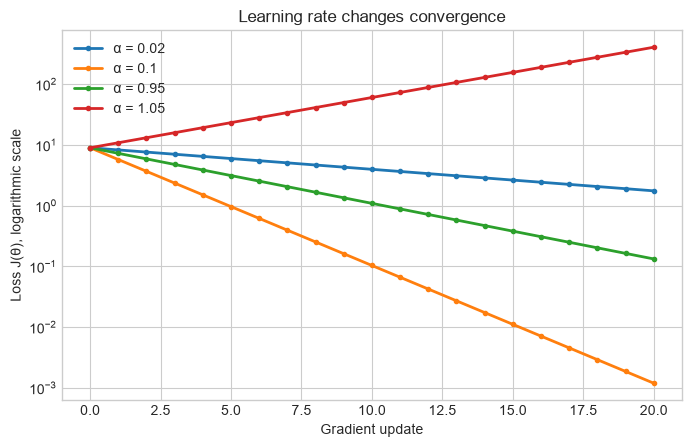

In [6]:
example_rates = [0.02, 0.10, 0.95, 1.05]

fig, ax = plt.subplots(figsize=(8, 4.8))
for rate in example_rates:
    _, losses = trace_quadratic_descent(0.0, rate, n_steps=20)
    ax.semilogy(losses, linewidth=2, marker="o", markersize=3, label=f"α = {rate}")

ax.set(title="Learning rate changes convergence", xlabel="Gradient update", ylabel="Loss J(θ), logarithmic scale")
ax.legend()
plt.show()


The learning rate of 0.02 reduces the loss steadily but slowly. Rates 0.10 and 0.95 converge much faster for this particular objective. The rate 1.05 increases the loss because each update overshoots by more than the previous one. This threshold is specific to the curvature of this objective; there is no universally safe learning rate.


<a id="linear-regression"></a>
## <font color="#4DAAFC"><strong>5. Move from one parameter to a fitted line</strong></font>

We now use the same mechanism to fit a line. Let $x_i\in\mathbb{R}$ be the feature and $y_i\in\mathbb{R}$ the observed target for observation $i$, where $i\in\{1,\ldots,N\}$. The model has two parameters:

- $w\in\mathbb{R}$: the slope or weight;
- $b\in\mathbb{R}$: the intercept or bias.

The parameter vector is therefore $\boldsymbol{\theta}=(w,b)$.


<a id="model-loss"></a>
### <font color="#4DAAFC"><strong>5.1 Model and loss</strong></font>

The prediction for observation $i$ is

$$
\hat{y}_i=wx_i+b, \tag{5.1}
$$

where $\hat{y}_i$ is the predicted target. The residual is $\hat{y}_i-y_i$: prediction minus observation.

We measure overall disagreement with the mean squared error (MSE):

$$
J(w,b)=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2. \tag{5.2}
$$

Mean squared error (MSE) squares every residual so that positive and negative errors cannot cancel, then averages those squared errors over the $N$ observations.


In [7]:
n_observations = 60
x = np.linspace(-2.5, 3.0, n_observations)
true_weight = 2.4
true_bias = -0.7
noise = rng.normal(loc=0.0, scale=0.65, size=n_observations)
y = true_weight * x + true_bias + noise

print(f"Feature shape: {x.shape}")
print(f"Target shape: {y.shape}")
print(f"First three observations: {np.round(np.column_stack((x, y))[:3], 3)}")


Feature shape: (60,)
Target shape: (60,)
First three observations: [[-2.5   -6.779]
 [-2.407 -6.491]
 [-2.314 -6.834]]


Both arrays have shape `(60,)`: one feature and one target for each of 60 observations. The noisy targets do not sit exactly on the hidden generating line, which makes the example closer to a real estimation problem.


<a id="linear-gradients"></a>
### <font color="#4DAAFC"><strong>5.2 Gradients for the weight and bias</strong></font>

Differentiating equation (5.2) with respect to each parameter gives

$$
\frac{\partial J}{\partial w}
=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)x_i, \tag{5.3}
$$

and

$$
\frac{\partial J}{\partial b}
=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i). \tag{5.4}
$$

The symbol $\partial$ denotes a partial derivative: the rate of change with respect to one parameter while the other parameter is temporarily held fixed.

Equation (5.3) weights each residual by its feature value because changing the slope affects predictions in proportion to $x_i$. Equation (5.4) averages the residual contribution because changing the intercept shifts every prediction equally.

The two updates are

$$
w^{(t+1)}=w^{(t)}-\alpha\frac{\partial J}{\partial w},
\qquad
b^{(t+1)}=b^{(t)}-\alpha\frac{\partial J}{\partial b}. \tag{5.5}
$$


<a id="gradient-function"></a>
### <font color="#4DAAFC"><strong>5.3 One vectorised gradient calculation</strong></font>

NumPy can calculate all predictions and residuals together. The function below returns the loss and both gradients so that one call corresponds to equations (5.1)–(5.4).


In [8]:
def validate_regression_data(
    features: np.ndarray,
    targets: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Validate a single-feature regression dataset.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Target values with the same shape.

    Returns
    -------
    features, targets
        Finite floating-point arrays with matching non-empty shapes.
    """
    features = np.asarray(features, dtype=float)
    targets = np.asarray(targets, dtype=float)
    if features.ndim != 1 or targets.ndim != 1 or features.size == 0:
        raise ValueError("features and targets must be non-empty one-dimensional arrays")
    if features.shape != targets.shape:
        raise ValueError("features and targets must have the same shape")
    if not np.all(np.isfinite(features)) or not np.all(np.isfinite(targets)):
        raise ValueError("features and targets must be finite")
    return features, targets


def linear_loss_and_gradients(
    features: np.ndarray,
    targets: np.ndarray,
    weight: float,
    bias: float,
) -> tuple[float, float, float]:
    """Calculate mean squared error and its two linear-model gradients.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Observed target values with shape ``(N,)``.
    weight
        Current line slope ``w``.
    bias
        Current line intercept ``b``.

    Returns
    -------
    loss
        Mean squared error for the current parameters.
    weight_gradient
        Partial derivative of the loss with respect to ``w``.
    bias_gradient
        Partial derivative of the loss with respect to ``b``.
    """
    features, targets = validate_regression_data(features, targets)
    predictions = weight * features + bias
    residuals = predictions - targets

    loss = np.mean(residuals**2)
    weight_gradient = 2.0 * np.mean(residuals * features)
    bias_gradient = 2.0 * np.mean(residuals)
    return float(loss), float(weight_gradient), float(bias_gradient)


In [9]:
initial_loss, initial_dw, initial_db = linear_loss_and_gradients(
    x,
    y,
    weight=0.0,
    bias=0.0,
)

print(f"Initial MSE: {initial_loss:.3f}")
print(f"Weight gradient ∂J/∂w: {initial_dw:.3f}")
print(f"Bias gradient ∂J/∂b: {initial_db:.3f}")


Initial MSE: 15.675
Weight gradient ∂J/∂w: -12.594
Bias gradient ∂J/∂b: 0.161


At the initial horizontal line `ŷ = 0`, both gradients are positive or negative according to this fixed dataset. Subtracting them in equation (5.5) moves the slope and intercept in the directions that locally reduce mean squared error. Their different magnitudes are expected because the two parameters affect predictions differently.


<a id="fit-runner"></a>
## <font color="#4DAAFC"><strong>6. Assemble batch gradient descent</strong></font>

**Batch gradient descent** uses all observations to calculate each update. The runner below repeatedly calls the same loss-and-gradient function developed in Section 5 and records the history for diagnosis.


In [10]:
@dataclass(frozen=True)
class GradientDescentResult:
    """Final parameters and recorded optimisation history."""

    weight: float
    bias: float
    losses: np.ndarray
    weights: np.ndarray
    biases: np.ndarray


def fit_linear_gradient_descent(
    features: np.ndarray,
    targets: np.ndarray,
    learning_rate: float = 0.05,
    n_steps: int = 300,
    initial_weight: float = 0.0,
    initial_bias: float = 0.0,
) -> GradientDescentResult:
    """Fit a one-feature linear model with batch gradient descent.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Target values with shape ``(N,)``.
    learning_rate
        Positive multiplier applied to both gradients.
    n_steps
        Number of parameter updates.
    initial_weight, initial_bias
        Starting line parameters.

    Returns
    -------
    GradientDescentResult
        Final parameters and histories including the initial state.
    """
    features, targets = validate_regression_data(features, targets)
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("learning_rate must be positive and finite")
    if n_steps < 1:
        raise ValueError("n_steps must be at least one")

    weight = float(initial_weight)
    bias = float(initial_bias)
    losses = []
    weights = [weight]
    biases = [bias]

    for _ in range(n_steps):
        loss, weight_gradient, bias_gradient = linear_loss_and_gradients(
            features, targets, weight, bias
        )
        losses.append(loss)
        weight -= learning_rate * weight_gradient
        bias -= learning_rate * bias_gradient
        weights.append(weight)
        biases.append(bias)

    final_loss, _, _ = linear_loss_and_gradients(features, targets, weight, bias)
    losses.append(final_loss)

    return GradientDescentResult(
        weight=weight,
        bias=bias,
        losses=np.asarray(losses),
        weights=np.asarray(weights),
        biases=np.asarray(biases),
    )


<a id="fit-model"></a>
## <font color="#4DAAFC"><strong>7. Fit and inspect the model</strong></font>

We use a learning rate of 0.05 for 300 updates. The fitted parameters should approach the relationship that generated the data, although random noise means they need not equal it exactly.


In [11]:
fitted = fit_linear_gradient_descent(
    x,
    y,
    learning_rate=0.05,
    n_steps=300,
)

print(f"Fitted weight: {fitted.weight:.3f} (generating value {true_weight:.1f})")
print(f"Fitted bias: {fitted.bias:.3f} (generating value {true_bias:.1f})")
print(f"Initial MSE: {fitted.losses[0]:.3f}")
print(f"Final MSE: {fitted.losses[-1]:.3f}")


Fitted weight: 2.424 (generating value 2.4)
Fitted bias: -0.686 (generating value -0.7)
Initial MSE: 15.675
Final MSE: 0.355


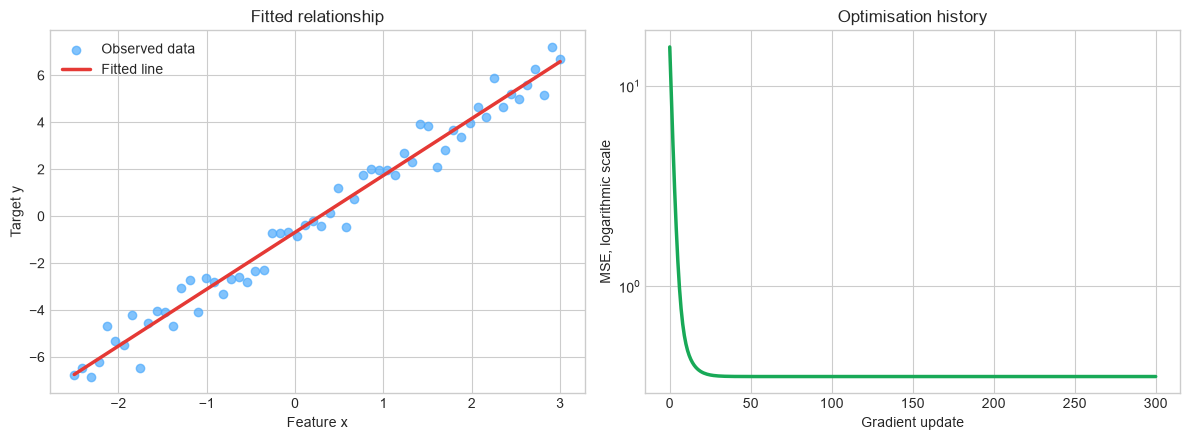

In [12]:
fitted_predictions = fitted.weight * x + fitted.bias

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(x, y, alpha=0.7, color=BLUE, label="Observed data")
axes[0].plot(x, fitted_predictions, color=RED, linewidth=2.5, label="Fitted line")
axes[0].set(title="Fitted relationship", xlabel="Feature x", ylabel="Target y")
axes[0].legend()

axes[1].semilogy(fitted.losses, color=GREEN, linewidth=2.5)
axes[1].set(title="Optimisation history", xlabel="Gradient update", ylabel="MSE, logarithmic scale")

plt.tight_layout()
plt.show()


The left panel shows that the fitted line follows the centre of the noisy observations. The right panel shows a smooth reduction in mean squared error (MSE), with large improvements early in training and progressively smaller changes near convergence. Together, the numerical output and plots indicate that the implementation is behaving as intended on this demonstration dataset.


<a id="compare-rates"></a>
## <font color="#4DAAFC"><strong>8. Compare learning rates</strong></font>

A useful diagnosis compares complete loss histories under different learning rates while keeping the starting values and data fixed.


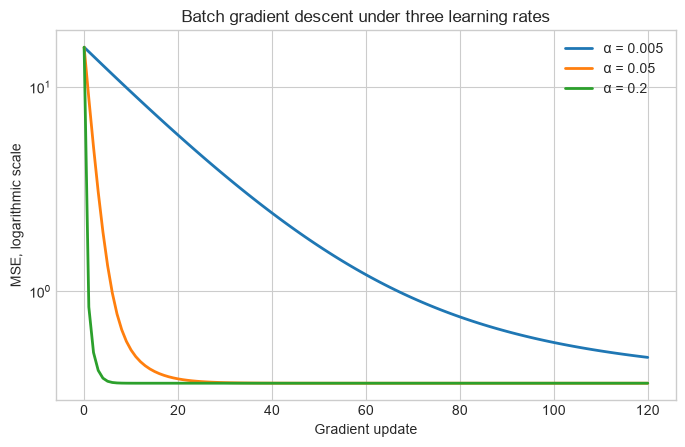

In [13]:
regression_rates = [0.005, 0.05, 0.20]

fig, ax = plt.subplots(figsize=(8, 4.8))
for rate in regression_rates:
    result = fit_linear_gradient_descent(x, y, learning_rate=rate, n_steps=120)
    ax.semilogy(result.losses, linewidth=2, label=f"α = {rate}")

ax.set(title="Batch gradient descent under three learning rates", xlabel="Gradient update", ylabel="MSE, logarithmic scale")
ax.legend()
plt.show()


The smallest rate makes gradual progress. The intermediate and larger rates reach the low-loss region more quickly on this well-scaled, one-feature problem. A larger value is not inherently better: with different feature scales or curvature it may become unstable. The loss history is therefore an important diagnostic, not merely a decorative plot.


<a id="checks"></a>
## <font color="#4DAAFC"><strong>9. Sanity checks and limitations</strong></font>

The next cell checks behaviours that should hold for this controlled example. These tests do not prove that the implementation is correct for every possible dataset, but they can expose common errors.


In [14]:
# Check the hand-worked calculation.
assert np.isclose(theta_1, 0.6)
assert quadratic_objective(theta_1) < quadratic_objective(theta_0)

# Check the fitted history and parameter estimates.
assert fitted.losses[-1] < fitted.losses[0]
assert np.all(np.diff(fitted.losses) <= 1e-10)
assert abs(fitted.weight - true_weight) < 0.25
assert abs(fitted.bias - true_bias) < 0.25

# Check an important input boundary.
try:
    fit_linear_gradient_descent(x, y[:-1])
except ValueError:
    mismatched_shapes_rejected = True
else:
    mismatched_shapes_rejected = False

assert mismatched_shapes_rejected
print("All demonstration checks passed.")


All demonstration checks passed.


### Limitations

- This is full-batch gradient descent on a small, single-feature linear model.
- Real applications may use **stochastic gradient descent (SGD)** or mini-batches rather than every observation in each update.
- Feature scaling becomes more important when predictors have very different magnitudes.
- Mean squared error is sensitive to unusually large residuals and is not appropriate for every problem.
- A falling training loss does not establish performance on unseen data; that requires a validation or test design.
- More complex objectives may contain saddle points, flat regions and multiple local minima.


<a id="summary"></a>
## <font color="#4DAAFC"><strong>10. Summary and next steps</strong></font>

Gradient descent repeatedly evaluates a local slope and updates parameters in the opposite direction. In this Learning Lab, the same idea moved a scalar towards the minimum of a quadratic objective and fitted the slope and intercept of a noisy straight-line relationship.

The central update was

$$
\boldsymbol{\theta}^{(t+1)}
=\boldsymbol{\theta}^{(t)}-\alpha\nabla J(\boldsymbol{\theta}^{(t)}),
$$

where $\nabla J$ is the vector of partial derivatives. The learning rate controls the step size, while the gradient supplies the direction.

Purposeful next steps include extending the implementation to several features, comparing batch and stochastic gradient descent, introducing feature scaling and examining adaptive optimisers used in neural networks.
